### 1. Data Ingestion and Inspection
In this section, the historical energy reservoir dataset is loaded into a pandas DataFrame to begin the analytical process. The initial rows are inspected using `df.head()` to verify the data structure, column names, and overall format before performing further manipulations or feeding the data into the Streamlit application.

In [26]:
import pandas as pd

# Read the reservoir dataset
df = pd.read_csv(r"C:\Users\lucab\OneDrive\Desktop\Ind320-LucaBergami-streamlit\reservoirs.csv")

# Print the first few rows to examine them
df.head()

,dato_Id,omrType,omrnr,iso_aar,iso_uke,fyllingsgrad,kapasitet_TWh,fylling_TWh,neste_Publiseringsdato,fyllingsgrad_forrige_uke,endring_fyllingsgrad
0,1995-09-03,EL,4,1995,35,0.944721,21.079208,19.913979,0001-01-01T00:00:00,0.936888,0.007833
1,2020-11-15,EL,1,2020,46,0.974361,6.003264,5.849344,2020-11-25T13:00:00,0.997406,-0.023046
2,2011-08-28,EL,4,2011,34,0.786499,21.079208,16.578772,0001-01-01T00:00:00,0.787193,-0.000694
3,1998-07-05,EL,3,1998,27,0.793969,8.920932,7.082947,0001-01-01T00:00:00,0.733812,0.060157
4,2011-03-27,EL,4,2011,12,0.300820,21.079208,6.341054,0001-01-01T00:00:00,0.311122,-0.010301


### 2. Data Preparation and Column Renaming
To ensure better readability and clarity during the analysis, the dataset columns are renamed into standardized English terms (such as `Date`, `Fill_Rate`, and `Capacity_TWh`). The modified structure is then verified using `df.head()`.

In [27]:
# Rename columns to clear English names
df = df.rename(columns={
    'dato_Id': 'Date',
    'omrType': 'Area_Type',
    'omrnr': 'Area_Code',
    'iso_aar': 'Year',
    'iso_uke': 'Week',
    'fyllingsgrad': 'Fill_Rate',
    'kapasitet_TWh': 'Capacity_TWh',
    'fylling_TWh': 'Filling_TWh',
    'neste_Publiseringsdato': 'Next_Publish_Date'
})

# Verify that the modificatiions was successful by printing the table again
df.head()




,Date,Area_Type,Area_Code,Year,Week,Fill_Rate,Capacity_TWh,Filling_TWh,Next_Publish_Date,fyllingsgrad_forrige_uke,endring_fyllingsgrad
0,1995-09-03,EL,4,1995,35,0.944721,21.079208,19.913979,0001-01-01T00:00:00,0.936888,0.007833
1,2020-11-15,EL,1,2020,46,0.974361,6.003264,5.849344,2020-11-25T13:00:00,0.997406,-0.023046
2,2011-08-28,EL,4,2011,34,0.786499,21.079208,16.578772,0001-01-01T00:00:00,0.787193,-0.000694
3,1998-07-05,EL,3,1998,27,0.793969,8.920932,7.082947,0001-01-01T00:00:00,0.733812,0.060157
4,2011-03-27,EL,4,2011,12,0.300820,21.079208,6.341054,0001-01-01T00:00:00,0.311122,-0.010301


### 3. Exploratory Data Analysis (EDA)
In this step, structural and statistical properties of the dataset are inspected. Using `df.info()`, the data types, total number of entries (14,877 records), and memory usage are verified, ensuring there are no unexpected null values. Furthermore, `df.describe()` is applied to generate key summary statistics for the numerical columns, providing a preliminary overview of distributions for metrics such as fill rates and capacities.

In [28]:
# Display general information about the dataset (data types and non-null values)
print("--- Dataset Information ---")
df.info()

# Display summary statistics for numerical columns to understand data distribution
print("\n--- Summary Statistics ---")
df.describe()

--- Dataset Information ---
<class 'pandas.DataFrame'>
RangeIndex: 14877 entries, 0 to 14876
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Date                      14877 non-null  str    
 1   Area_Type                 14877 non-null  str    
 2   Area_Code                 14877 non-null  int64  
 3   Year                      14877 non-null  int64  
 4   Week                      14877 non-null  int64  
 5   Fill_Rate                 14877 non-null  float64
 6   Capacity_TWh              14877 non-null  float64
 7   Filling_TWh               14877 non-null  float64
 8   Next_Publish_Date         14877 non-null  str    
 9   fyllingsgrad_forrige_uke  14877 non-null  float64
 10  endring_fyllingsgrad      14877 non-null  float64
dtypes: float64(5), int64(3), str(3)
memory usage: 1.7 MB

--- Summary Statistics ---


,Area_Code,Year,Week,Fill_Rate,Capacity_TWh,Filling_TWh,fyllingsgrad_forrige_uke,endring_fyllingsgrad
count,14877.000000,14877.000000,14877.000000,14877.000000,14877.000000,14877.000000,14877.000000,14877.000000
mean,2.333333,2010.346038,26.405929,0.618852,29.145860,18.139713,0.618890,-0.000038
std,1.490762,9.146696,15.017910,0.214850,22.739070,15.966211,0.214843,0.031385
min,0.000000,1995.000000,1.000000,0.055160,6.003264,0.331142,0.055160,-0.242484
25%,1.000000,2002.000000,13.000000,0.456234,17.390587,7.321973,0.456356,-0.022395
50%,2.000000,2010.000000,26.000000,0.648049,23.237715,14.501389,0.648114,-0.007072
75%,3.000000,2018.000000,39.000000,0.802135,34.043590,22.203530,0.802133,0.016277
max,5.000000,2026.000000,53.000000,1.020072,87.437580,84.544820,1.020037,0.336623


### 4. Time Series Trend Visualization
In this section, a time series analysis is performed using `matplotlib`. First, the `Date` column is properly converted to datetime format to ensure correct chronological plotting on the x-axis. The data is then aggregated by date using `groupby` and averaged to handle potential duplicates and provide a smooth trend line. Finally, a loop generates customized line plots for key metrics (`Fill_Rate`, `Capacity_TWh`, and `Filling_TWh`), complete with grid formatting, custom colors, and clear labels.

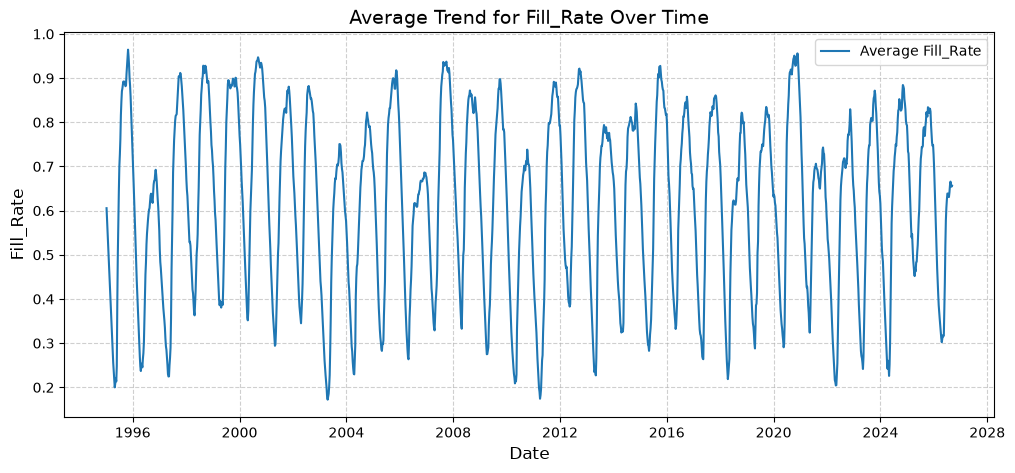

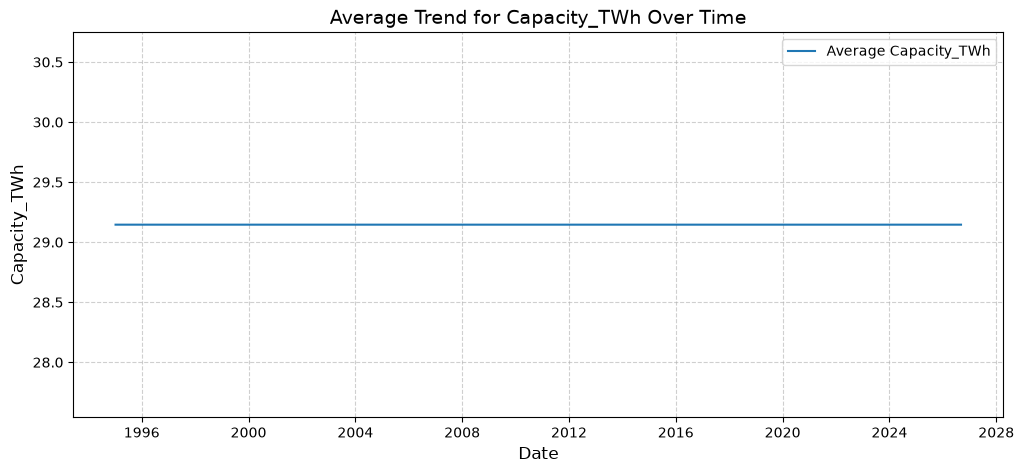

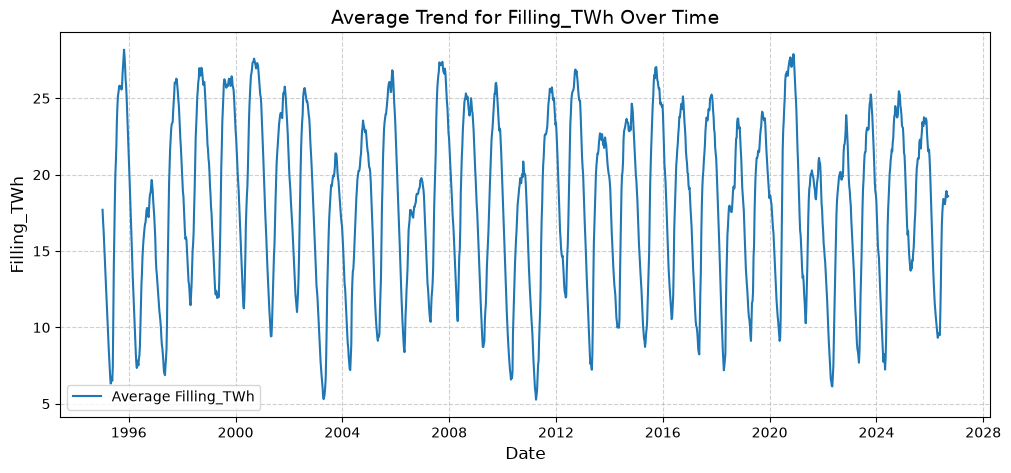

In [29]:
import matplotlib.pyplot as plt
import pandas as pd

# Here i make sure that Python reads the 'Date' column properly, so that Matplotlib can plot it correctly on x-axis overtime
df['Date'] = pd.to_datetime(df['Date'])

# The FIX: I'm grouping the data by Date and taking the mean
# This helps clean up daily duplicates or multiple records, giving us a single smooth trend line 
df_trend = df.groupby('Date')[["Fill_Rate", "Capacity_TWh", "Filling_TWh"]].mean().reset_index()

# Metrics to visualize
metric_options = ["Fill_Rate", "Capacity_TWh", "Filling_TWh"]

# Here I loop through each metric to generate a separate plot for each one 
for metric in metric_options:
    plt.figure(figsize=(12, 5))
    
    # Plotting the clean, aggregated data chronologically
    plt.plot(df_trend['Date'], df_trend[metric], label=f"Average {metric}", color='#1f77b4', linewidth=1.5)
    
    # Adding titles, clear axis labels, and a grid to make the chart easier to read
    plt.title(f"Average Trend for {metric} Over Time", fontsize=14)
    plt.xlabel("Date", fontsize=12)
    plt.ylabel(metric, fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()
    
    plt.show()

### 5. Extra Analytics and Summary Metrics
This final section computes high-level summary indicators from the dataset, specifically calculating the overall average capacity (in TWh) and the average fill rate (converted to a percentage). These aggregated statistics provide a quick numerical overview before concluding the notebook and linking the analysis to the Streamlit application.

In [30]:
# Here i calculate some extra stats from the dataset were cleaned before
# i'm finding the avarage capacity in TWh using our renamed column
average_capacity = df['Capacity_TWh'].mean()

# Here I calculate the average fill rate and convert it to a percentage
average_fill_rate = df['Fill_Rate'].mean() * 100

# Printing out the results just to double check them
print("--- Extra Analytics & Statistics ---")
print("Here you can find a quick summary of key data extracted from the dataset.\n")

print(f"Average Total Capacity: {average_capacity:.2f} TWh")
print(f"Average Fill Rate: {average_fill_rate:.1f}%")

# This is just a final message to ensure that everything looks good
print("\n✅ All project pages have been successfully configured!")

--- Extra Analytics & Statistics ---
Here you can find a quick summary of key data extracted from the dataset.

Average Total Capacity: 29.15 TWh
Average Fill Rate: 61.9%

✅ All project pages have been successfully configured!


### Project Log & Workflow
The work began by configuring the local development environment using Python, Docker, and VS Code, establishing a solid foundation to handle historical datasets of energy reservoirs.

The initial phase focused on data analysis and cleaning within the Jupyter Notebook. I loaded the datasets using `pandas`, handled missing or anomalous values, and performed preliminary statistical checks to understand the underlying data structure (`df.head()` and core metrics). Once the analytical logic was fully verified inside the notebook, I moved on to developing the Streamlit application.

The application was structured into multiple distinct pages to ensure a clean and user-friendly experience:
* **Home (`app.py`):** Acts as the landing page, featuring the initial system configuration (`st.set_page_config`) and clear navigation instructions via the sidebar menu.
* **Data Table (`2_Data_Table.py`):** Handles tabular exploration of the data, allowing users to filter, inspect, and analyze raw dataset records dynamically.
* **Data Plot (`3_Data_Plot.py`):** Focuses on visual analytics, transforming complex multi-metric trends into interactive charts.

Since this was the first time I tackled the development of a web application, the overall experience was genuinely stimulating. Approaching the implementation step-by-step helped me grasp how the entire pipeline works—from backend data processing in the notebook to the final frontend interface. Putting all the pieces together and testing everything hands-on really helped me tie everything up and see how all parts of project connected together.

### 2_Data_Table.py:
### 6. Streamlit Implementation: Data Table & Sparklines (`2_Data_Table.py`)
In this section, I developed the first dedicated page of my Streamlit application. To optimize performance while loading and cleaning the raw CSV dataset, I implemented a caching mechanism (`@st.cache_data`) to avoid redundant reloads.

For the data preparation steps, i've cleaned the whitespace in column names, translating the headers into standardized English terms, and converting the date formats properly. Furthermore, I structured the logic to isolate the first active month of data, compute daily averages, and leverage Streamlit's advanced `column_config.LineChartColumn` configuration. This allowed me to embed interactive micro-charts (sparklines) directly inside the summary table for a clean and effective visual overview.

```python
# 2_Data_Table.py
import streamlit as st
import pandas as pd

st.title("Interactive reservoir table")
st.markdown("This page displays the first month's trend for each imported metric.")

@st.cache_data
def load_and_clean_data():
    # Load the dataset using a relative path 
    df = pd.read_csv("reservoirs.csv")
    
    # I.ve uesed this command to clean invisible spaces from column names
    df.columns = df.columns.str.strip()
    
    # Rename columns to English
    df = df.rename(columns={
        'dato_Id': 'Date',
        'omrType': 'Area_Type',
        'omrnr': 'Area_Code',
        'iso_aar': 'Year',
        'iso_uke': 'Week',
        'fyllingsgrad': 'Fill_Rate',
        'kapasitet_TWh': 'Capacity_TWh',
        'fylling_TWh': 'Filling_TWh',
        'neste_Publiseringsdato': 'Next_Publish_Date'
    })
    
    # Convert Date to datetime format for filtering
    df['Date'] = pd.to_datetime(df['Date'])
    return df

df = load_and_clean_data()

# 1. Isolate the first month of the dataset
first_month = df['Date'].min().to_period('M')
df_first_month = df[df['Date'].dt.to_period('M') == first_month]

# 2. Group by date to get a single daily average
daily_trend = df_first_month.groupby('Date')[['Fill_Rate', 'Capacity_TWh', 'Filling_TWh']].mean()

# 3. Create a new dataframe where each row represents a column from the original data
chart_data = pd.DataFrame({
    "Metric": ["Fill Rate", "Capacity (TWh)", "Filling (TWh)"],
    "First Month Trend": [
        daily_trend['Fill_Rate'].tolist(),
        daily_trend['Capacity_TWh'].tolist(),
        daily_trend['Filling_TWh'].tolist()
    ]
})

st.subheader("First Month Trend Overview")

# 4. Display using st.dataframe and column_config for the sparkline
st.dataframe(
    chart_data,
    column_config={
        "First Month Trend": st.column_config.LineChartColumn(
            "Trend (First Month Only)",
            width="medium"
        )
    },
    hide_index=True,
    use_container_width=True
)
```

### 3_Data_Plot.py:
In this section, I built the interactive visualization page of the application. The script handles loading and cleaning the dataset, grouping it by date to ensure smooth trends, and formatting a monthly string column (`Month_Year`) to power a custom interactive timeline slider.

Users can dynamically select specific metrics or view all of them combined. To be honest, the most interesting part I worked on here was implementing the Min-Max normalization, which allowed me to plot metrics with completely different scales (such as percentages and TWh) together on the same chart without distortion. Finally, I integrated Matplotlib within Streamlit (`st.pyplot`) to render clean, grid-formatted time series charts over the custom-filtered date ranges.

```python
#3_Data_Plot.py
import streamlit as st
import pandas as pd
import matplotlib.pyplot as plt

st.title("Reservoir chart")
st.markdown("Visualizing the fill level trend over time")

@st.cache_data
def load_data():
    # Load the dataset using a relative path
    df = pd.read_csv("reservoirs.csv")
    
    # Clean invisible spaces from column names
    df.columns = df.columns.str.strip()
    
    # Rename columns to English
    df = df.rename(columns={
        'dato_Id': 'Date',
        'omrType': 'Area_Type',
        'omrnr': 'Area_Code',
        'iso_aar': 'Year',
        'iso_uke': 'Week',
        'fyllingsgrad': 'Fill_Rate',
        'kapasitet_TWh': 'Capacity_TWh',
        'fylling_TWh': 'Filling_TWh',
        'neste_Publiseringsdato': 'Next_Publish_Date'
    })
    
    df['Date'] = pd.to_datetime(df['Date'])
    
    # Group by date to get a clean average and remove daily duplicates
    df_trend = df.groupby('Date')[['Fill_Rate', 'Capacity_TWh', 'Filling_TWh']].mean().reset_index()
    
    # Create a specific column in "YYYY-MM" format for the monthly slider
    df_trend['Month_Year'] = df_trend['Date'].dt.strftime('%Y-%m')
    
    return df_trend

df = load_data()

# 1. Here I create a dropdown menu with an "All" option to choose which metric to display
metric_options = ["All", "Fill_Rate", "Capacity_TWh", "Filling_TWh"]
selected_metric = st.selectbox("Select the metric to analyze:", options=metric_options)

# 2. Time slider based on months
unique_months = df['Month_Year'].sort_values().unique()

# Set the default value to the first month (unique_months[0]) for both ends
selected_months = st.select_slider(
    "Select the month range:",
    options=unique_months,
    value=(unique_months[0], unique_months[0])
)

# Filter data based on the slider selection
start_month, end_month = selected_months
filtered_df = df[(df['Month_Year'] >= start_month) & (df['Month_Year'] <= end_month)]

st.subheader(f"Trend for {selected_metric}")

# 3. Create the chart with Matplotlib to handle axis titles and different scales
fig, ax = plt.subplots(figsize=(10, 5))

if selected_metric == "All":
    # Min-Max normalization to plot metrics with different scales (TWh and percentages)
    for col in ["Fill_Rate", "Capacity_TWh", "Filling_TWh"]:
        min_val = filtered_df[col].min()
        max_val = filtered_df[col].max()
        
        # Avoid division by zero if the value is constant during the selected period
        if min_val != max_val:
            normalized_col = (filtered_df[col] - min_val) / (max_val - min_val)
        else:
            normalized_col = pd.Series(1.0, index=filtered_df.index)
            
        ax.plot(filtered_df['Date'], normalized_col, label=f"Normalized {col}")
    
    # Force Y-axis to stay between 0 and 1 with a small margin
    ax.set_ylim(-0.1, 1.1)
    ax.set_ylabel("Normalized Scale (0-1)")
else:
    # Plot the single selected metric
    ax.plot(filtered_df['Date'], filtered_df[selected_metric], label=selected_metric, color='#1f77b4')
    ax.set_ylabel(selected_metric)

# Add formatting, titles, and grid as requested
ax.set_title("Reservoirs Trend Over Time")
ax.set_xlabel("Date")
ax.grid(True, linestyle='--', alpha=0.6)
ax.legend()

# Render the chart in the Streamlit interface
st.pyplot(fig)
```

### 4_Extra.py:
This section features the code for the concluding utility page of the application. The script reloads and cleans the core dataset, and leverages Streamlit’s layout column components (`st.columns`) to present high-level summary metrics side-by-side. 

Specifically, it calculates and renders the overall average capacity (in TWh) and the average fill rate (formatted as a percentage), concluding the interface with a confirmation notification (`st.success`) indicating that all project components have been successfully configured.

```python
import streamlit as st
import pandas as pd

st.title("Extra Analytics & Statistics")
st.markdown("Here you can find a quick summary of key data extracted from the dataset.")

@st.cache_data
def load_data():
    # Load the dataset using a relative path
    file_path = "reservoirs.csv"
    df = pd.read_csv(file_path)
    
    # Clean potential invisible spaces around column names
    df.columns = df.columns.str.strip()
    
    # Rename columns to English
    df = df.rename(columns={
        'dato_Id': 'Date',
        'omrType': 'Area_Type',
        'omrnr': 'Area_Code',
        'iso_aar': 'Year',
        'iso_uke': 'Week',
        'fyllingsgrad': 'Fill_Rate',
        'kapasitet_TWh': 'Capacity_TWh',
        'fylling_TWh': 'Filling_TWh',
        'neste_Publiseringsdato': 'Next_Publish_Date'
    })
    return df

# Load the dataframe
df = load_data()

# Display the metrics in two layout columns
col1, col2 = st.columns(2)

with col1:
    # Display the average capacity
    st.metric("Average Total Capacity", f"{df['Capacity_TWh'].mean():.2f} TWh")

with col2:
    # Display the average fill rate converted to a percentage
    st.metric("Average Fill Rate", f"{df['Fill_Rate'].mean()*100:.1f}%")

# Display final success message
st.success("All project pages have been successfully configured!")
```

### app.py:
This section documents the primary entry point and home page of the Streamlit application. The script establishes the global page configuration (`st.set_page_config`), defining the application title, custom icon, and a wide layout. Furthermore, it introduces the IND320 Norwegian Reservoir project overview, provides clear navigation instructions for the sidebar menu, and displays a user-friendly info banner to guide visitors.

```python
import streamlit as st

st.set_page_config(
    page_title="IND320 Reservoir Dashboard",
    page_icon="⚡",
    layout="wide"
)

st.title("Welcome to IND320 Project - Norwegian Reservoirs")
st.markdown("""
This interactive web application was developed to analyze historical data on energy reservoirs.

### How to navigate the app:
- Use the **left sidebar** to switch between the different sections:
    - **Interactive Table**: To explore and filter the complete dataset.
    - **Reservoir Plot**: To visualize the fill rate trend.
    - **Extra**: Additional section for customized analysis.
""")

st.info("Use the sidebar menu to start exploring the data.")
```

### AI Usage
During the development of this project, artificial intelligence was used as a collaborative co-pilot to support the technical implementation and coding process. Specifically, the AI assisted in:

* Code Drafting & Implementation: Helping translate the functional and analytical logic of the project into working Python and Streamlit code.
* Debugging & Troubleshooting: Supporting the identification and resolution of syntax errors, data manipulation bugs, and visualization issues.
* Structuring & Documentation: Assisting in organizing the multi-page application workflow and adding clear, descriptive comments to the codebase.

Useful Links:


Streamlit: https://ind320-lucabergami-app-j4cx7lvst9tcwnnphrgw9e.streamlit.app

Video: https://nmbu.cloud.panopto.eu/Panopto/Pages/Viewer.aspx?id=09cde4b3-da22-43af-86f3-b4d30180270d

Github: https://github.com/LukeBerg13/IND320-LucaBergami-App